# Day 10 Assignment: Image Generation with Diffusion Models
###Name: Divyashree R

### Objective
The goal of this assignment is to explore **diffusion-based image generation** using the Hugging Face `diffusers` library.

We use a pretrained **Stable Diffusion model** to generate images from text prompts. Diffusion models work by gradually transforming random noise into meaningful images guided by textual descriptions.


In [ ]:
!pip install diffusers transformers accelerate torch
!pip install safetensors

In [ ]:
from diffusers import DiffusionPipeline
import torch
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
pipe = DiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

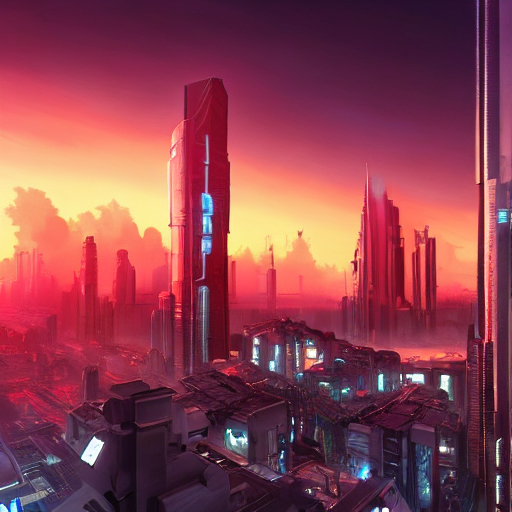

In [ ]:
prompt = "a futuristic city at sunset, cyberpunk style, ultra realistic"
image = pipe(prompt).images[0]
image

In [ ]:
prompts = [
    "a dragon flying over a medieval castle at sunset",
    "an astronaut riding a horse on mars, realistic",
    "a futuristic robot cooking in a kitchen"
]
images = []
for p in prompts:
    img = pipe(p).images[0]
    images.append(img)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

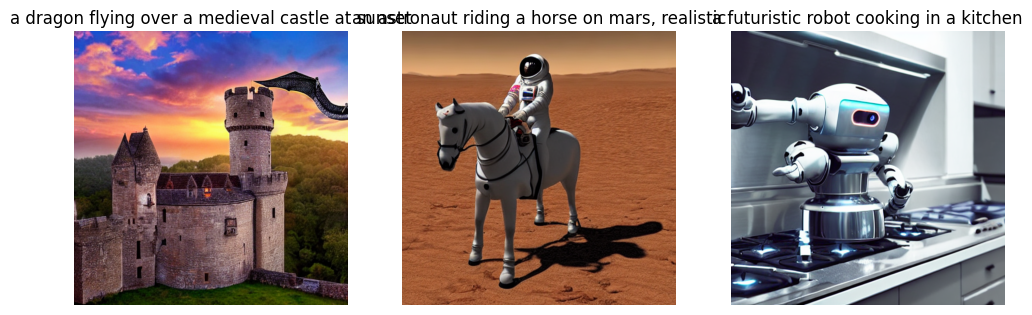

In [ ]:
plt.figure(figsize=(12,4))
for i, img in enumerate(images):
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(prompts[i])
    plt.axis("off")
plt.show()

## Observations

The Stable Diffusion v1.5 model from Hugging Face was used to generate images from text prompts.

### Prompts Used
- A dragon flying over a medieval castle at sunset
- An astronaut riding a horse on Mars, realistic
- A futuristic robot cooking in a kitchen

### Results
The model generated visually detailed and creative images that closely matched the prompts. It captured different artistic styles, environments, and objects effectively.


### Conclusion
Diffusion models are powerful generative AI systems capable of producing high-quality images from natural language descriptions.